# Desafío - Inferencia y pruebas de hipótesis
### Nombre: Matías Ignacio Ramírez Benavides

## Descripción
Eres analista de datos para "Café Rápido", una popular cadena de cafeterías. La gerencia
quiere entender mejor la experiencia de sus clientes y ha realizado una encuesta de
satisfacción a nivel nacional. Tu misión es analizar una muestra de estos datos para estimar
la satisfacción promedio real de todos los clientes y el porcentaje que calificaría su
experiencia como "excelente".
* Objetivo: Aplicar técnicas de inferencia estadística para estimar parámetros
poblacionales (media y proporción) a partir de una muestra, calculando e
interpretando intervalos de confianza y determinando el tamaño muestral adecuado
para futuras mediciones.
Dataset: Para este desafío, simularemos un dataset poblacional de calificaciones de
clientes. Ejecuta el siguiente código para generar los datos con los que trabajarás:

In [21]:
import pandas as pd
import numpy as np
from IPython.display import display # importa la función display para mostrar DataFrames de manera más legible en Jupyter Notebook
# Generar datos poblacionales simulados
np.random.seed(42)
datos_poblacion = {
'calificacion': np.random.normal(loc=8.5, scale=1.5, size=5000).clip(1,10),
'recomienda': np.random.choice([1, 0], size=5000, p=[0.75, 0.25])
}
poblacion_df = pd.DataFrame(datos_poblacion)
poblacion_df['calificacion'] = poblacion_df['calificacion'].round(1)
# Extraer una muestra aleatoria para el análisis
muestra_df = poblacion_df.sample(n=100, random_state=101)
print("Muestra de datos (primeras 5 filas):")
display(muestra_df.head())
print(f"\nEl tamaño de la muestra es de {len(muestra_df)} clientes.\n")
muestra_df.info()
print("\nNo presenta valores nulos")

Muestra de datos (primeras 5 filas):


,calificacion,recomienda
1718,9.6,0
2511,9.3,1
345,8.8,1
2521,10.0,1
54,10.0,1



El tamaño de la muestra es de 100 clientes.

<class 'pandas.DataFrame'>
Index: 100 entries, 1718 to 2911
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   calificacion  100 non-null    float64
 1   recomienda    100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 2.3 KB

No presenta valores nulos


## Requerimientos
### 1. Inferencia sobre la Media con Desviación Estándar Conocida (2 Puntos)
Históricamente, "Café Rápido" sabe que la desviación estándar (σ) de la calificación
de sus clientes a nivel nacional es de 1.5. 
Utilizando la muestra muestra_df,
calcula el intervalo de confianza del 95% para la media de la calificación.
* Paso 1: Calcula la media de la calificación en tu muestra.
* Paso 2: Utiliza la fórmula del intervalo de confianza para la media con σ
conocida: IC=overlinexpmzcdotfracsigmasqrtn (Considera z=1.96 para un
95% de confianza).
* Paso 3: Interpreta el resultado en una frase.

In [53]:
# Media muestral
media = muestra_df["calificacion"].mean()


sigma = 1.5 # Desviación estándar poblacional conocida
z = 1.96 # Nivel de confianza del 95%
n = len(muestra_df) # Tamaño de la muestra
error_estandar = sigma / np.sqrt(n) # Error estándar
margen_error = z * error_estandar # Margen de error

# Intervalo de confianza (IC)
limite_inferior = media - margen_error
limite_superior = media + margen_error

print(f"""{"="*15}  RESULTADOS  {"="*15}
Media muestral: {media:.2f}
IC 95%: Limite inferior: {limite_inferior:.2f}
        Limite Superior: {limite_superior:.2f}
""")

===============  RESULTADOS  ===============
Media muestral: 8.41
IC 95%: Limite inferior: 8.12
        Limite Superior: 8.71



### 2. Inferencia sobre la Media con Desviación Estándar Desconocida (2 Puntos)
Ahora, supón que no conoces la desviación estándar de la población. Calcula el
intervalo de confianza del 95% para la media de la calificación basándote
únicamente en los datos de tu muestra.
* Paso 1: Calcula la media y la desviación estándar de la calificación en tu
muestra.
* Paso 2: Utiliza la fórmula del intervalo de confianza para la media con σ
desconocida (usando la distribución t-Student):
IC=overlinexpmtcdotfracssqrtn (Puedes usar
scipy.stats.t.ppf(0.975, df=n-1) para obtener el valor de t).
* Paso 3: Compara este intervalo con el obtenido en el requerimiento 1. ¿Es
más ancho o más estrecho? ¿Por qué?


In [54]:
# Media y desviación estándar muestral
media = muestra_df["calificacion"].mean()
Des_Estandar = muestra_df["calificacion"].std(ddof=1)

from scipy.stats import t
n = len(muestra_df) # Tamaño de la muestra
t_critico = t.ppf(0.975, df= n-1) # Valor crítico de t para un 95% de confianza
error_estandar_2 = Des_Estandar / np.sqrt(n) # Error estándar
margen_error_2 = t_critico * error_estandar_2 # Margen de error

# Intervalo de confianza
limite_inferior_2 = media - margen_error_2
limite_superior_2 = media + margen_error_2

print(f"""{"="*15}  RESULTADOS  {"="*15}
Media: {media:.2f}
Desviación estándar: {Des_Estandar:.2f}
Valor t: {t_critico:.4f}
IC 95%: Limite inferior: {limite_inferior_2:.2f}
        Limite Superior: {limite_superior_2:.2f}

{"="*15}  COMPARACIÓN IC {"="*15}
Pregunta 1: IC = ({limite_inferior:.2f},{limite_superior:.2f})
Pregunta 2: IC = ({limite_inferior_2:.2f},{limite_superior_2:.2f})

  • ¿Es más ancho o más estrecho? ¿Por qué?
  
Sí. Al comparar los resultados, el intervalo de la Pregunta 2 es más estrecho 
que el de la Pregunta 1.
Esto en teoría se debe a que el intervalo con la distribución t suele ser más ancho 
por la mayor incertidumbre al desconocer la desviación estándar poblacional. Sin embargo, 
en este caso fue más estrecho porque la desviación estándar muestral obtenida (1.29) fue 
menor que σ = 1.5, reduciendo el margen de error.
""")



===============  RESULTADOS  ===============
Media: 8.41
Desviación estándar: 1.29
Valor t: 1.9842
IC 95%: Limite inferior: 8.16
        Limite Superior: 8.67

===============  COMPARACIÓN IC ===============
Pregunta 1: IC = (8.12,8.71)
Pregunta 2: IC = (8.16,8.67)

  • ¿Es más ancho o más estrecho? ¿Por qué?

Sí. Al comparar los resultados, el intervalo de la Pregunta 2 es más estrecho 
que el de la Pregunta 1.
Esto en teoría se debe a que el intervalo con la distribución t suele ser más ancho 
por la mayor incertidumbre al desconocer la desviación estándar poblacional. Sin embargo, 
en este caso fue más estrecho porque la desviación estándar muestral obtenida (1.29) fue 
menor que σ = 1.5, reduciendo el margen de error.



### 3. Inferencia sobre una Proporción (2 Puntos)
La gerencia considera una experiencia "excelente" si el cliente indica que
recomendaría el café (valor 1 en la columna recomienda). Calcula el intervalo de
confianza del 95% para la proporción de clientes que recomiendan "Café Rápido".
* Paso 1: Calcula la proporción muestral (hatp) de clientes que recomiendan.
* Paso 2: Aplica la fórmula del intervalo de confianza para una proporción: IC=hatppmzcdotsqrtfrachatp(1−hatp)n
* Paso 3: Escribe una conclusión sobre el rango en que se podría encontrar la
verdadera proporción de clientes satisfechos.


In [68]:
# Proporción muestral (hatp)
p_hat = muestra_df["recomienda"].mean() # Forma manual p_hat = muestra_df["recomienda"].sum() / len(muestra_df)

n = len(muestra_df) # Tamaño de la muestra
z = 1.96 # Nivel de confianza 95%
error = np.sqrt((p_hat * (1 - p_hat)) / n) # Error estándar de la proporción
margen = z * error # Margen de error

# Intervalo de confianza
limite_inferior_3 = p_hat - margen
limite_superior_3 = p_hat + margen

print(f"""{"="*15}  RESULTADOS  {"="*15}
Proporción muestral: {p_hat:.2f}
IC 95%: Limite inferior: {limite_inferior_3:.2f}
        Limite Superior: {limite_superior_3:.2f}

Con un 95% de confianza, la verdadera proporción de clientes que
recomiendan "Café Rápido" se encuentra entre {limite_inferior_3:.2f} y {limite_superior_3:.2f}.
""")

===============  RESULTADOS  ===============
Proporción muestral: 0.74
IC 95%: Limite inferior: 0.65
        Limite Superior: 0.83

Con un 95% de confianza, la verdadera proporción de clientes que
recomiendan "Café Rápido" se encuentra entre 0.65 y 0.83.



### 4. Impacto del Nivel de Confianza (2 Puntos)
El equipo de marketing necesita estar muy seguro de sus estimaciones para una
nueva campaña publicitaria. Vuelve a calcular el intervalo de confianza para la media
con desviación estándar desconocida (como en el requerimiento 2), pero esta vez
con un nivel de confianza del 99%.
* Paso 1: Obtén el valor crítico de t para un 99% de confianza.
* Paso 2: Calcula el nuevo intervalo.
* Paso 3: Explica cómo y por qué el aumento en el nivel de confianza afecta la
amplitud del intervalo.


In [69]:
t_critico_99 = t.ppf(0.995, df=n-1) # Nivel de confianza del 99%
error_estandar = Des_Estandar / np.sqrt(n) # Error estándar
margen_99 = t_critico_99 * error_estandar # Margen de error

# Intervalo
limite_inferior_99 = media - margen_99
limite_superior_99 = media + margen_99

print(f"""{"="*15}  RESULTADOS  {"="*15}
Valor crítico t (99%): {t_critico_99:.2f}
IC 99%: Limite inferior: {limite_inferior_99:.2f}
        Limite Superior: {limite_superior_99:.2f}

Al aumentar el nivel de confianza desde un 95% a un 99%, el intervalo
de confianza se vuelve más amplio ya que paso de ({limite_inferior_2:.2f}, {limite_superior_2:.2f}) a ({limite_inferior_99:.2f}, {limite_superior_99:.2f}). 
Esto ocurre porque se necesita un mayor margen de error para tener una mayor certeza de que la media
poblacional se encuentra dentro del intervalo.
""")


===============  RESULTADOS  ===============
Valor crítico t (99%): 2.63
IC 99%: Limite inferior: 8.07
        Limite Superior: 8.75

Al aumentar el nivel de confianza desde un 95% a un 99%, el intervalo
de confianza se vuelve más amplio ya que paso de (8.16, 8.67) a (8.07, 8.75). 
Esto ocurre porque se necesita un mayor margen de error para tener una mayor certeza de que la media
poblacional se encuentra dentro del intervalo.



### 5. Cálculo del Tamaño de la Muestra (2 Puntos)
Para el próximo estudio de satisfacción, la gerencia quiere que la estimación de la
proporción de clientes que recomiendan el café tenga un margen de error máximo
del 4% (E = 0.04) con un nivel de confianza del 95%.
* Paso 1: Utiliza la fórmula para el cálculo del tamaño de la muestra para una
proporción: n=fracz2cdothatp(1−hatp)E2 (Usa la proporción hatp que
calculaste en el requerimiento 3 como una estimación). 

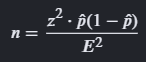
* Paso 2: Indica cuántos clientes se deberían encuestar para cumplir con este
requisito. Recuerda redondear hacia el entero superior.

In [67]:
z = 1.96 # Nivel de confianza del 95%
E = 0.04 # Margen de error máximo permitido
p = p_hat # Proporción estimada obtenida en la pregunta 3
n_requerido = (z**2 * p * (1 - p)) / (E**2) # Cálculo del tamaño muestral
n_requerido = np.ceil(n_requerido) # Redondear hacia arriba

print(f"""{"="*15}  RESULTADOS  {"="*15}
Tamaño mínimo de la muestra: {int(n_requerido)} clientes

Para estimar la proporción de clientes que recomiendan "Café Rápido"
con un margen de error máximo del 4% y un nivel de confianza del 95%,
es necesario encuestar al menos {int(n_requerido)} clientes.
""")

===============  RESULTADOS  ===============
Tamaño mínimo de la muestra: 462 clientes

Para estimar la proporción de clientes que recomiendan Café Rápido
con un margen de error máximo del 4% y un nivel de confianza del 95%,
es necesario encuestar al menos 462 clientes.

